In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from os import path
path1 ='/content/drive/MyDrive/railway power query '
df= pd.read_excel(path1)
print(df.head())

            transaction_id purchase_date purchase_time purchase_type  \
0  7837fefa-5e1c-4a24-a6ac    2024-01-01      20:22:05        Online   
1  452320e9-a181-4457-821d    2024-01-02      20:18:10        Online   
2  93d61511-514a-4285-942f    2024-01-02      20:20:20        Online   
3  f526d406-784e-49d0-8d75    2024-01-02      20:21:59        Online   
4  776063a2-0b90-4dcd-bdff    2024-01-03      20:19:31        Online   

  payment_method rail_card ticket_class ticket_type  price  departure_station  \
0    Credit Card       NaN     Standard     Advance      8  London St Pancras   
1    Credit Card       NaN     Standard     Advance      8  London St Pancras   
2    Credit Card       NaN     Standard     Advance      8  London St Pancras   
3    Credit Card       NaN     Standard     Advance      8  London St Pancras   
4    Credit Card       NaN     Standard     Advance      8  London St Pancras   

     arrival_destination journey_date departure_time arrival_time  \
0  Birmingh

In [ ]:
print(df.isnull().sum())

transaction_id             0
purchase_date              0
purchase_time              0
purchase_type              0
payment_method             0
rail_card              20918
ticket_class               0
ticket_type                0
price                      0
departure_station          0
arrival_destination        0
journey_date               0
departure_time             0
arrival_time               0
actual_arrival_time        0
delay_time                 0
journey_status             0
delay_reason               0
refund_request             0
dtype: int64


In [ ]:
purchase_type = df['purchase_type'].value_counts()
print("Purchase Type Distribution:\n", purchase_type)

Purchase Type Distribution:
 purchase_type
Online     18521
Station    13132
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
revenue_by_method = df.groupby('payment_method')['price'].sum()
print("Revenue by Payment Method:\n", revenue_by_method)


Revenue by Payment Method:
 payment_method
Contactless    219444
Credit Card    469511
Debit Card      52966
Name: price, dtype: int64


In [ ]:
revenue_by_method = df.groupby('payment_method')['price'].sum().sort_values()

fig = go.Figure(data=[
    go.Bar(x=revenue_by_method.index, y=revenue_by_method.values, marker_color='skyblue')
])
fig.update_layout(title='Revenue by Payment Method', xaxis_title='Payment Method', yaxis_title='Total Revenue (£)')
fig.show()

In [ ]:
rail_card_usage = df['rail_card'].value_counts()
print("Rail Card Usage:\n", rail_card_usage)
labels_2 = ['Adult', 'Disabled', 'Senior']
values_2 = [rail_card_usage['Adult'], rail_card_usage['Disabled'], rail_card_usage['Senior']]
colors = ['baby_blue', 'gray', 'lightgray']
fig = go.Figure(data=[go.Pie(labels=labels_2, values=values_2, hole=.3, marker_colors=colors)])
fig.update_layout(title='rail_card_type')
fig.show()

Rail Card Usage:
 rail_card
Adult       4846
Disabled    3089
Senior      2800
Name: count, dtype: int64


In [ ]:
ticket_sales_by_class = df.groupby('ticket_class')['transaction_id'].count()
print("Ticket Sales by Class:\n", ticket_sales_by_class)

Ticket Sales by Class:
 ticket_class
First Class     3058
Standard       28595
Name: transaction_id, dtype: int64


In [ ]:
ticket_type_dist = df['ticket_type'].value_counts(normalize=True) * 100
print("Ticket Type Distribution (%):\n", ticket_type_dist)

Ticket Type Distribution (%):
 ticket_type
Advance     55.479733
Off-Peak    27.649828
Anytime     16.870439
Name: proportion, dtype: float64


In [ ]:
top_departure = df['departure_station'].value_counts().head(5)
print("Top Departure Stations:\n", top_departure)

Top Departure Stations:
 departure_station
Manchester Piccadilly    5650
London Euston            4954
Liverpool Lime Street    4561
London Paddington        4500
London Kings Cross       4229
Name: count, dtype: int64


In [ ]:
top_arrival = df['arrival_destination'].value_counts().head(5)
print("Top Arrival Stations:\n", top_arrival)

Top Arrival Stations:
 arrival_destination
Birmingham New Street    7742
Liverpool Lime Street    5022
York                     4019
Manchester Piccadilly    3968
Reading                  3920
Name: count, dtype: int64


In [ ]:
total_journeys = df['transaction_id'].count()
on_time_journeys = df[df['journey_status'] == 'On Time']['transaction_id'].count()
delayed_journeys = df[df['journey_status'] == 'Delayed']['transaction_id'].count()
cancelled_journeys = df[df['journey_status'] == 'Cancelled']['transaction_id'].count()
print("Total Journeys:", total_journeys)
print("On Time Journeys:", on_time_journeys)
print("Delayed Journeys:", delayed_journeys)
print("Cancelled Journeys:", cancelled_journeys)

Total Journeys: 31653
On Time Journeys: 27481
Delayed Journeys: 2292
Cancelled Journeys: 1880


In [ ]:

labels = ['on time', 'delayed', 'cancelled']
values = [on_time_journeys, delayed_journeys, cancelled_journeys]
colors = ['baby_blue', 'gray', 'lightgray']
fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3, marker_colors=colors)])
fig.update_layout(title='Journey Status Distribution')
fig.show()

In [ ]:
df['route'] = df['departure_station'] + " → " + df['arrival_destination']
delayed_routes = df[df['journey_status'] != 'On Time'].groupby('route').size().sort_values(ascending=False).head(5)
print("Most Frequently Delayed & Cancelled Routes:\n", delayed_routes)

Most Frequently Delayed & Cancelled Routes:
 route
Liverpool Lime Street → London Euston            879
Manchester Piccadilly → Liverpool Lime Street    644
London Euston → Birmingham New Street            453
London Paddington → Reading                      352
London Kings Cross → York                        329
dtype: int64


In [ ]:
weather_conditions = df[df['delay_reason']=="Weather Conditions"]['transaction_id'].count()
signal_failures = df[df['delay_reason']=="Signal Failure"]['transaction_id'].count()
staffing =  df[df['delay_reason']=="Staffing"]['transaction_id'].count()
technical_issues = df[df['delay_reason']=="Technical Issue"]['transaction_id'].count()
traffic = df[df['delay_reason']=="Traffic"]['transaction_id'].count()
print("Weather Conditions:\n", weather_conditions)
print("Signal Failures:\n", signal_failures)
print("Staffing:\n", staffing)
print("Technical Issues:\n", technical_issues)
print("Traffic:\n", traffic)


Weather Conditions:
 1372
Signal Failures:
 970
Staffing:
 809
Technical Issues:
 707
Traffic:
 314


In [ ]:
total_revenue = df['price'].sum()
print("Total Revenue:", total_revenue)
total_refunds = df[df['refund_request'] == "Yes"]['price'].sum()
print("Total Refunds:", total_refunds)
net_revenue = total_revenue - total_refunds
print("Net Revenue:", net_revenue)

Total Revenue: 741921
Total Refunds: 38702
Net Revenue: 703219


In [ ]:
route_revenue = df.groupby('route')['price'].sum().sort_values(ascending=False)
print("Top Revenue Routes:\n", route_revenue)

Top Revenue Routes:
 route
London Kings Cross → York                    183193
Liverpool Lime Street → London Euston        113299
London Paddington → Reading                   65368
London Euston → Manchester Piccadilly         61004
London St Pancras → Birmingham New Street     52869
                                              ...  
Bristol Temple Meads → Cardiff Central           98
York → Leeds                                     78
Birmingham New Street → Wolverhampton            60
Manchester Piccadilly → Warrington               53
London Euston → Oxford                           41
Name: price, Length: 64, dtype: int64


In [ ]:
df['purchase_hour_am_pm'] = pd.to_datetime(df['purchase_time'].astype(str)).dt.strftime('%I %p')
price_by_hour_am_pm = df.groupby('purchase_hour_am_pm')['price'].mean().sort_index()
print("Average Ticket Price by Purchase Hour (AM/PM):\n", price_by_hour_am_pm)

<ipython-input-19-636864067f72>:1: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



Average Ticket Price by Purchase Hour (AM/PM):
 purchase_hour_am_pm
01 AM    17.668605
01 PM    20.183024
02 AM    25.917445
02 PM    17.699304
03 AM    23.109304
03 PM    32.816757
04 AM    22.945887
04 PM    19.038826
05 AM    27.109195
05 PM    18.668978
06 AM    57.962827
06 PM    22.671579
07 AM    23.857283
07 PM    10.513793
08 AM    18.052291
08 PM    17.700313
09 AM    33.221739
09 PM    17.092496
10 AM    15.957877
10 PM    10.131004
11 AM    18.589502
11 PM    20.440771
12 AM    22.920000
12 PM    17.734634
Name: price, dtype: float64


In [ ]:
def get_time_period(hour):
    if 6 <= hour <= 8:
        return 'Morning Peak'
    elif 16 <= hour <= 18:
        return 'Evening Peak'
    else:
        return 'Off-Peak'

df['departure_hour'] = pd.to_datetime(df['departure_time'].astype(str)).dt.hour
df['time_period'] = df['departure_hour'].apply(get_time_period)

peak_stats = df.groupby('time_period').agg(
    ticket_sales=('transaction_id', 'count'),
    total_revenue=('price', 'sum')
)
print("Peak vs Off-Peak Stats:\n", peak_stats)

Peak vs Off-Peak Stats:
               ticket_sales  total_revenue
time_period                              
Evening Peak          8302         171631
Morning Peak          8086         279559
Off-Peak             15265         290731


<ipython-input-20-45e002cbfec5>:9: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [ ]:
import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(go.Bar(
    x=peak_stats.index,
    y=peak_stats['ticket_sales'],
    name='Ticket Sales',
    marker_color='lightskyblue',
    yaxis='y'
))

In [ ]:
df['journey_date'] = pd.to_datetime(df['journey_date'], errors='coerce')
df['month'] = df['journey_date'].dt.month
monthly_revenue = df.groupby('month')['price'].sum()
print("Monthly Revenue:\n", monthly_revenue)

Monthly Revenue:
 month
1    199618
2    159374
3    195147
4    187782
Name: price, dtype: int64


Text(0, 0.5, 'Total Revenue (£)')

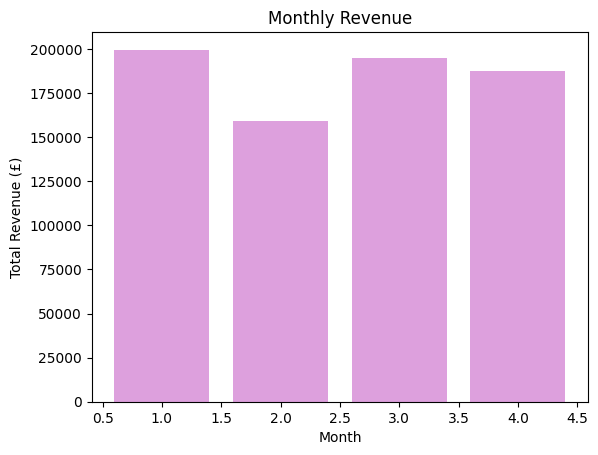

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
plt.bar(monthly_revenue.index, monthly_revenue.values, color='#dda0dd')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')

In [ ]:
df['week']= df['journey_date'].dt.to_period('w').apply(lambda r: r.start_time.strftime('%Y-%m-%d'))
weekly_revenue = df.groupby('week')['price'].sum()
print("Weekly Revenue:\n", weekly_revenue)

<ipython-input-24-d0dec74d3f6b>:1: FutureWarning:

'w' is deprecated and will be removed in a future version, please use 'W' instead.



Weekly Revenue:
 week
2024-01-01    37941
2024-01-08    46752
2024-01-15    45069
2024-01-22    47584
2024-01-29    47579
2024-02-05    38811
2024-02-12    40280
2024-02-19    34762
2024-02-26    32543
2024-03-04    47299
2024-03-11    45403
2024-03-18    44599
2024-03-25    45517
2024-04-01    36415
2024-04-08    46914
2024-04-15    47050
2024-04-22    45760
2024-04-29    11643
Name: price, dtype: int64


In [ ]:
weekly_revenue = weekly_revenue.reset_index()
weekly_revenue['week'] = pd.to_datetime(weekly_revenue['week'])
weekly_revenue.rename(columns={'price': 'weekly_sales'}, inplace=True)
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=weekly_revenue['week'],
        y=weekly_revenue['weekly_sales'],
        mode='lines+markers',
        name='Weekly Revenue',
        marker=dict(color='purple')
    ))
fig.update_layout(
    title='Weekly Revenue',
    xaxis_title='Week',
    yaxis_title='Total Revenue (£)',
    xaxis=dict(tickangle=-45)
)
fig.show()

In [ ]:
pd.set_option('display.max_rows',None)
route_summary = df.groupby('route').agg(
    trips=('departure_time', 'nunique'),
    passengers=('transaction_id', 'count')
    ).reset_index()

print(route_summary)

                                            route  trips  passengers
0                Birmingham New Street → Coventry      1          65
1      Birmingham New Street → Edinburgh Waverley      1          16
2   Birmingham New Street → Liverpool Lime Street     11         175
3           Birmingham New Street → London Euston      7         125
4      Birmingham New Street → London Kings Cross      1          17
5       Birmingham New Street → London Paddington      2          32
6       Birmingham New Street → London St Pancras     11         702
7   Birmingham New Street → Manchester Piccadilly      2         224
8                Birmingham New Street → Nuneaton      2         219
9                 Birmingham New Street → Reading      3          47
10               Birmingham New Street → Stafford      3         190
11               Birmingham New Street → Tamworth      2         227
12          Birmingham New Street → Wolverhampton      1          32
13                   Birmingham Ne

In [ ]:
df['z_score'] = (df['price'] - df['price'].mean()) / df['price'].std()
outliers = df[df['z_score'].abs() < 1]
print("Outliers:\n", outliers[['journey_date','transaction_id', 'price', 'z_score']])

Streaming output truncated to the last 5000 lines.
25395   2024-02-19  3c875a05-14ea-4c0f-8943      4 -0.648025
25396   2024-02-20  74be081e-eff7-4082-a0d6      4 -0.648025
25397   2024-02-25  04950157-2376-485a-b42a      4 -0.648025
25398   2024-02-24  72c2f90a-6652-4271-816c      4 -0.648025
25399   2024-02-25  c8cea064-a781-46c5-9ae9      4 -0.648025
25400   2024-03-04  063e09a7-4b4b-42ce-a705      4 -0.648025
25401   2024-03-05  d500349d-4bb7-4541-8923      4 -0.648025
25402   2024-03-06  25617bcd-ff4d-4ff9-8928      4 -0.648025
25403   2024-03-06  0082284d-7298-466e-b7e7      4 -0.648025
25404   2024-03-06  e63deee5-986c-431b-b908      4 -0.648025
25405   2024-03-08  79c26750-1d81-4343-b5fc      4 -0.648025
25406   2024-03-08  96fdb7fd-baa0-4407-9ae8      4 -0.648025
25407   2024-03-10  37fcc0ea-4c20-4b3c-8a88      4 -0.648025
25408   2024-03-10  6244b1d1-0a32-4f5e-b60b      4 -0.648025
25409   2024-03-11  ca9d227e-44fe-4e50-8914      4 -0.648025
25410   2024-03-14  3af23620-0d1c-

In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
df['purchase_date'] = pd.to_datetime(df['purchase_date'], errors='coerce')
df['month'] = df['purchase_date'].dt.to_period('M')
status_counts = df.groupby(['month', 'journey_status']).size().unstack().fillna(0)
status_counts.index = status_counts.index.to_timestamp()
forecast_results = {}
from statsmodels.tsa.arima.model import ARIMA
delayed_model = ARIMA(status_counts['Delayed'], order=(5, 1, 0))
delayed_model_fit = delayed_model.fit()
delayed_forecast = delayed_model_fit.forecast(steps=4)
print("Delayed Forecast (Next 4 Months):")
print(delayed_forecast)
on_time_model = ARIMA(status_counts['On Time'], order=(5, 1, 0))
on_time_model_fit = on_time_model.fit()
on_time_forecast = on_time_model_fit.forecast(steps=4)
print("\nOn Time Forecast (Next 4 Months):")
print(on_time_forecast)
cancelled_model = ARIMA(status_counts['Cancelled'], order=(5, 1, 0))
cancelled_model_fit = cancelled_model.fit()
cancelled_forecast = cancelled_model_fit.forecast(steps=4)
print("\nCancelled Forecast (Next 4 Months):")
print(cancelled_forecast)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



Delayed Forecast (Next 4 Months):
2024-05-01    1079.889806
2024-06-01    1099.933923
2024-07-01    1226.828442
2024-08-01    1045.352229
Freq: MS, Name: predicted_mean, dtype: float64


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.




On Time Forecast (Next 4 Months):
2024-05-01    14057.177741
2024-06-01    13285.893435
2024-07-01    13842.965121
2024-08-01    13376.509210
Freq: MS, Name: predicted_mean, dtype: float64

Cancelled Forecast (Next 4 Months):
2024-05-01     79.968211
2024-06-01    273.204135
2024-07-01    -21.531576
2024-08-01    312.848424
Freq: MS, Name: predicted_mean, dtype: float64


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



<ipython-input-29-32d3658bd527>:5: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



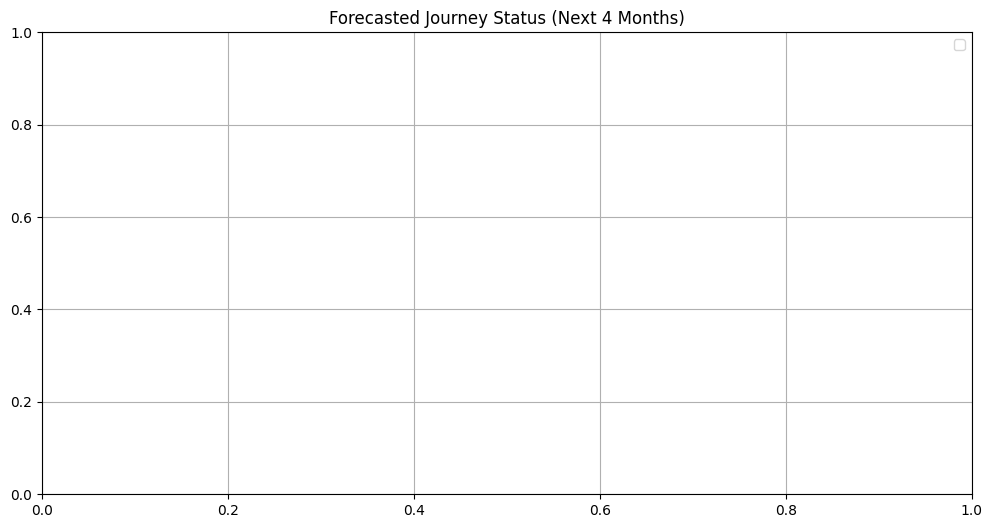

In [ ]:
plt.figure(figsize=(12, 6))
for status in forecast_results:
    plt.plot(pd.date_range(start=sales_monthly.index[-1] + pd.Timedelta(days=1), periods=4, freq='M'), forecast_results[status], label=f'Forecast - {status}')
plt.title('Forecasted Journey Status (Next 4 Months)')
plt.legend()
plt.grid()
plt.show()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.



Next 4 Months Sales:
2024-05-01    196374.134876
2024-06-01    191168.733608
2024-07-01    194322.338941
2024-08-01    192411.779873
Freq: MS, Name: predicted_mean, dtype: float64


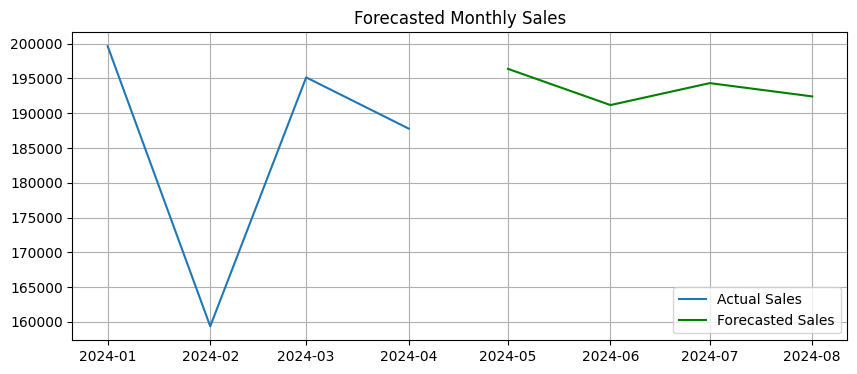

In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
df['journey_date'] = pd.to_datetime(df['journey_date'])
sales_monthly = df.groupby(df['journey_date'].dt.to_period('M'))['price'].sum().to_timestamp()

model = ARIMA(sales_monthly, order=(1, 1, 1))
model_fit = model.fit()
forecast_sales = model_fit.forecast(steps=4)
print("Next 4 Months Sales:")
print(forecast_sales)

plt.figure(figsize=(10, 4))
plt.plot(sales_monthly, label='Actual Sales')
plt.plot(forecast_sales, label='Forecasted Sales', color='green')
plt.title('Forecasted Monthly Sales')
plt.legend()
plt.grid()
plt.show()


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8ms_1z_q/myncc0hs.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8ms_1z_q/uwj1qcwe.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=95255', 'data', 'file=/tmp/tmp8ms_1z_q/myncc0hs.json', 'init=/tmp/tmp8ms_1z_q/uwj1qcwe.json', 'output', 'file=/tmp/tmp8ms_1z_q/prophet_modelode6_t1l/prophet_model-20250424130517.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:05:17 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:05:23 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages/

            ds       yhat  yhat_lower  yhat_upper
95  2024-04-05  24.980518  -15.038553   66.500582
96  2024-04-06  22.795662  -16.858098   62.530190
97  2024-04-07  22.752289  -14.693537   58.073532
98  2024-04-08  25.121806  -13.155796   65.029382
99  2024-04-09  25.266133  -11.385551   65.102006
100 2024-04-10  24.997474  -14.119286   62.568803
101 2024-04-11  23.641063  -12.527177   64.564288
102 2024-04-12  24.819363  -12.742471   63.760216
103 2024-04-13  22.598475  -15.729204   60.256257
104 2024-04-14  22.519070  -18.145639   60.298319
105 2024-04-15  24.888586  -12.659022   62.234692
106 2024-04-16  25.032914  -12.931792   60.629263
107 2024-04-17  24.764254  -12.272907   62.594226
108 2024-04-18  23.407844  -17.286916   62.585566
109 2024-04-19  24.586144  -13.882718   62.888464
110 2024-04-20  22.365255  -15.096399   59.023321
111 2024-04-21  22.285851  -15.316103   60.167421
112 2024-04-22  24.655367  -14.020346   65.514005
113 2024-04-23  24.799694  -14.734391   61.562534


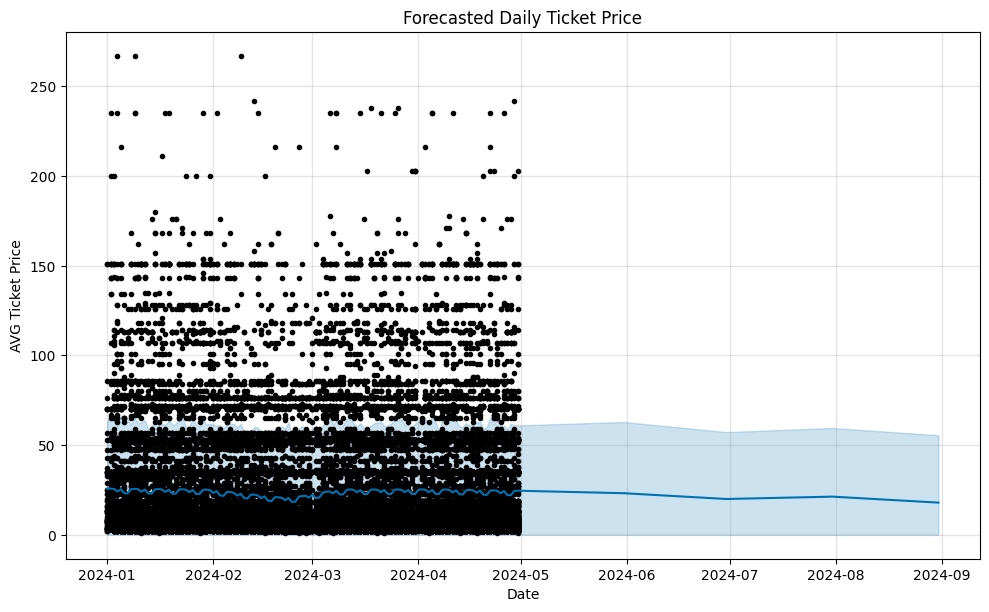

In [ ]:
!pip install prophet
from prophet import Prophet
df_prophet = df[['journey_date', 'price']].rename(columns={'journey_date': 'ds', 'price': 'y'})
model = Prophet()
model.fit(df_prophet)
future = model.make_future_dataframe(periods=4, freq='M')
forecast = model.predict(future)
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30))
forecast['yhat'] = forecast['yhat'].apply(lambda x: max(x, 0))
forecast['yhat_lower'] = forecast['yhat_lower'].apply(lambda x: max(x, 0))
forecast['yhat_upper'] = forecast['yhat_upper'].apply(lambda x: max(x, 0))
fig = model.plot(forecast)
plt.title('Forecasted Daily Ticket Price')
plt.xlabel('Date')
plt.ylabel('AVG Ticket Price')
plt.show()

In [ ]:
total_current_revenue=total_revenue
target_revenue = total_current_revenue * 1.20
revenue_gain = target_revenue - total_current_revenue
print("Current Revenue:", total_current_revenue)
print("Target Revenue:", target_revenue)
print("Revenue Gain to Achieve Target:", revenue_gain)

Current Revenue: 741921
Target Revenue: 890305.2
Revenue Gain to Achieve Target: 148384.19999999995


In [ ]:
route_summary['passengers_per_trip'] = route_summary['passengers'] / route_summary['trips']
print(route_summary)

                                            route  trips  passengers  \
0                Birmingham New Street → Coventry      1          65   
1      Birmingham New Street → Edinburgh Waverley      1          16   
2   Birmingham New Street → Liverpool Lime Street     11         175   
3           Birmingham New Street → London Euston      7         125   
4      Birmingham New Street → London Kings Cross      1          17   
5       Birmingham New Street → London Paddington      2          32   
6       Birmingham New Street → London St Pancras     11         702   
7   Birmingham New Street → Manchester Piccadilly      2         224   
8                Birmingham New Street → Nuneaton      2         219   
9                 Birmingham New Street → Reading      3          47   
10               Birmingham New Street → Stafford      3         190   
11               Birmingham New Street → Tamworth      2         227   
12          Birmingham New Street → Wolverhampton      1        

In [ ]:
current_number_of_trips=route_summary['trips'].sum()
avg_ticket_price=df['price'].mean()
average_ticket_price = avg_ticket_price
revenue_per_trip = route_summary['passengers_per_trip'] * average_ticket_price
average_revenue_per_trip = revenue_per_trip.mean()
print("Average Revenue per Trip:", average_revenue_per_trip)
required_trips = target_revenue / average_revenue_per_trip
additional_trips_needed = required_trips - current_number_of_trips
print("Current Number of Trips:", current_number_of_trips)
print("Required Trips to Achieve Target Revenue:", required_trips)
print("Additional Trips Needed:", additional_trips_needed)

Average Revenue per Trip: 1197.1632231874794
Current Number of Trips: 576
Required Trips to Achieve Target Revenue: 743.6790428873503
Additional Trips Needed: 167.6790428873503


In [ ]:
low_efficiency_routes = route_summary[route_summary['passengers_per_trip'] < 17]
print("Low Efficiency Routes:\n", low_efficiency_routes)

Low Efficiency Routes:
                                             route  trips  passengers  \
1      Birmingham New Street → Edinburgh Waverley      1          16   
2   Birmingham New Street → Liverpool Lime Street     11         175   
5       Birmingham New Street → London Paddington      2          32   
9                 Birmingham New Street → Reading      3          47   
14         Bristol Temple Meads → Cardiff Central      1          16   
16  Liverpool Lime Street → Birmingham New Street      1          14   
20      Liverpool Lime Street → London Paddington      2          27   
21      Liverpool Lime Street → London St Pancras      2          31   
26                         London Euston → Oxford      1          16   
31      London Paddington → Liverpool Lime Street      3          44   
33      London Paddington → Manchester Piccadilly      2          30   
42     Manchester Piccadilly → London Kings Cross      1          16   
44      Manchester Piccadilly → London S

In [ ]:
total_low_trips = low_efficiency_routes['trips'].sum()
total_low_passengers = low_efficiency_routes['passengers'].sum()
print("Total Trips on Low Efficiency Routes:", total_low_trips)
print("Total Passengers on Low Efficiency Routes:", total_low_passengers)

Total Trips on Low Efficiency Routes: 39
Total Passengers on Low Efficiency Routes: 604


In [ ]:
import plotly.express as px
fig = px.bar(low_efficiency_routes.sort_values(by='passengers_per_trip'),
             x='route',
             y='passengers_per_trip',
             title='Passengers per Trip on Low Efficiency Routes',
             labels={'passengers_per_trip': 'Passengers per Trip'},
             color='passengers_per_trip',color_continuous_scale='blues')
fig.update_layout(xaxis_tickangle=-45,height=500,title_font_size=18)
fig.show()

In [ ]:
import plotly.express as px
def get_time_period(hour):
    if 6 <= hour <= 8:
        return 'Morning Peak'
    elif 16 <= hour <= 18:
        return 'Evening Peak'
    else:
        return 'Off-Peak'
df['departure_hour'] = pd.to_datetime(df['departure_time'].astype(str)).dt.hour
df['time_period'] = df['departure_hour'].apply(get_time_period)

def what_if_analysis(increase_percentage, period_filter):
    filtered_df = df[df['time_period'].isin(period_filter)]
    total_current_revenue = filtered_df['price'].sum()
    target_revenue = total_current_revenue * (1 + increase_percentage / 100)
    revenue_gain = target_revenue - total_current_revenue

    print(f"Current Revenue for {', '.join(period_filter)}: {total_current_revenue}")
    print(f"Target Revenue after {increase_percentage}% increase: {target_revenue}")
    print(f"Revenue Gain to Achieve Target: {revenue_gain}")
    route_summary = filtered_df.groupby('route').agg(
        passengers=('transaction_id', 'count'),
        total_revenue=('price', 'sum')
    ).reset_index()
    route_summary['passengers_per_trip'] = route_summary['passengers'] / route_summary['route'].nunique()
    avg_ticket_price = df['price'].mean()
    average_revenue_per_trip = (route_summary['passengers_per_trip'] * avg_ticket_price).mean()

    current_number_of_trips = route_summary['route'].nunique()
    required_trips = target_revenue / average_revenue_per_trip
    additional_trips_needed = required_trips - current_number_of_trips

    print(f"Current Number of Trips: {current_number_of_trips}")
    print(f"Required Trips to Achieve Target Revenue: {required_trips}")
    print(f"Additional Trips Needed: {additional_trips_needed}")

    low_efficiency_routes = route_summary[route_summary['passengers_per_trip'] < 70]
    print(f"Low Efficiency Routes:\n {low_efficiency_routes}")

    fig = px.bar(low_efficiency_routes.sort_values(by='passengers_per_trip'),
                 x='route',
                 y='passengers_per_trip',
                 title='Passengers per Trip on Low Efficiency Routes',
                 labels={'passengers_per_trip': 'Passengers per Trip'},
                 color='passengers_per_trip', color_continuous_scale='blues')
    fig.update_layout(xaxis_tickangle=-45, height=500, title_font_size=18)
    fig.show()

what_if_analysis(20, ['Morning Peak', 'Evening Peak'])
what_if_analysis(20, ['Off-Peak'])

<ipython-input-46-30021f6034e4>:9: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



Current Revenue for Morning Peak, Evening Peak: 451190
Target Revenue after 20% increase: 541428.0
Revenue Gain to Achieve Target: 90238.0
Current Number of Trips: 51
Required Trips to Achieve Target Revenue: 3666.167662139556
Additional Trips Needed: 3615.167662139556
Low Efficiency Routes:
                                             route  passengers  total_revenue  \
0                Birmingham New Street → Coventry          65            269   
1   Birmingham New Street → Liverpool Lime Street          62            619   
2           Birmingham New Street → London Euston          78           2289   
3      Birmingham New Street → London Kings Cross          17            535   
4       Birmingham New Street → London Paddington          32            718   
5       Birmingham New Street → London St Pancras         509          13177   
6   Birmingham New Street → Manchester Piccadilly         128           1445   
7                Birmingham New Street → Nuneaton         219     

Current Revenue for Off-Peak: 290731
Target Revenue after 20% increase: 348877.2
Revenue Gain to Achieve Target: 58146.20000000001
Current Number of Trips: 38
Required Trips to Achieve Target Revenue: 1407.9919979358758
Additional Trips Needed: 1369.9919979358758
Low Efficiency Routes:
                                             route  passengers  total_revenue  \
0      Birmingham New Street → Edinburgh Waverley          16            798   
1   Birmingham New Street → Liverpool Lime Street         113           1171   
2           Birmingham New Street → London Euston          47           1305   
3       Birmingham New Street → London St Pancras         193           5834   
4   Birmingham New Street → Manchester Piccadilly          96           1062   
5                 Birmingham New Street → Reading          47           2212   
6         Edinburgh Waverley → London Kings Cross          51           2093   
7   Liverpool Lime Street → Birmingham New Street          14           

In [ ]:
df['departure_hour'] = df['departure_time'].apply(lambda x: x.hour)
def get_time_period(hour):
    if 6 <= hour <= 8:
        return 'Morning Peak'
    elif 16 <= hour <= 18:
        return 'Evening Peak'
    else:
        return 'Off-Peak'
df['time_period'] = df['departure_hour'].apply(get_time_period)
low_efficiency_routes = route_summary[route_summary['passengers_per_trip'] < 17]
low_efficiency_trips = df[df['route'].isin(low_efficiency_routes['route'])]
low_efficiency_in_peak = low_efficiency_trips[
    low_efficiency_trips['time_period'].isin(['Morning Peak', 'Evening Peak'])]
low_efficiency_in_peak_count = low_efficiency_in_peak.shape[0]
print("Number of Low Efficiency Trips in Peak Hours:", low_efficiency_in_peak_count)

Number of Low Efficiency Trips in Peak Hours: 262


In [ ]:
avg_ticket_price = df['price'].mean()
route_summary['passengers_per_trip'] = route_summary['passengers'] / route_summary['trips']
route_summary['revenue_per_trip'] = route_summary['passengers_per_trip'] * avg_ticket_price
sorted_routes = route_summary.sort_values(by='revenue_per_trip', ascending=False)
sorted_routes['cumulative_trips'] = sorted_routes['trips'].cumsum()
top_routes = sorted_routes.head(10)

print(top_routes[['route', 'revenue_per_trip', 'trips']])

                                            route  revenue_per_trip  trips
34                     London Paddington → Oxford      11368.012037      1
37                  London St Pancras → Leicester       3949.505213      2
28        London Kings Cross → Edinburgh Waverley       3820.589612      1
55                              Reading → Swindon       2672.068809      2
11               Birmingham New Street → Tamworth       2660.349209      2
7   Birmingham New Street → Manchester Piccadilly       2625.190408      2
8                Birmingham New Street → Nuneaton       2566.592408      2
57                               York → Doncaster       2472.835608      2
19          Liverpool Lime Street → London Euston       2337.527498     11
45             Manchester Piccadilly → Nottingham       1851.696806      2
